# Experimental Evaluation

In [1]:
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List

## Change here time limit for the benchmark. Do not modify this variable below.
MAX_TIME = 600.00

font = {
        'size'   : 11}
mpl.rc('font', **font)

## Helper functions

In [2]:
def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)

In [3]:
def set_size(width_pt, fraction=1, subplots=(1, 1)):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)


In [4]:
def set_square_size(width_pt, fraction=1):
    """Set figure dimensions to sit nicely in our document.

    Parameters
    ----------
    width_pt: float
            Document width in points
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    return (fig_width_in, fig_width_in)

In [5]:
def csv_info(table, verdict_str, time_str):
    print("Number of instances:", table.shape[0])
    print("SAT:", table.query(verdict_str + " == 'sat'").shape[0])
    print("UNSAT:", table.query(verdict_str + " == 'unsat'").shape[0])
    print("SAT or UNSAT:", table.query(verdict_str + " == 'sat' or " + verdict_str + " == 'unsat'").shape[0])
    print("UNKNOWN:", table.query(verdict_str + " == 'unknown'").shape[0])
    print("TIMEOUT:", table.query(verdict_str + " == 'timeout'").shape[0])
    count_errors = table[table[verdict_str].str.contains("error:", na=False)].shape[0]
    print("ERROR:", count_errors)

In [6]:
def plot_survival(table, solvers, verdict_types, labels, colors, y_text, plot_name):
    solver_times_sorted = {}
    solver_cumulative_sol = {}
    solver_plot = {}
    
    plt.figure(figsize=(8,6))
    
    for solver in solvers:
        verdict_col = f'verdict_{solver}'
        time_col = f'time_{solver}'
        
        times = table.loc[table[verdict_col].isin(verdict_types), time_col]
        times = pd.to_numeric(times, errors='coerce').dropna()
    
        solver_times_sorted[solver] = np.sort(times)
        solver_cumulative_sol[solver] = np.arange(1, len(solver_times_sorted[solver])+1)
    
        solver_plot[solver] = np.clip(solver_times_sorted[solver], min_time, None)
        solver_plot[solver] = np.append(solver_plot[solver], max_time)
        solver_cumulative_sol[solver] = np.append(solver_cumulative_sol[solver], solver_cumulative_sol[solver][-1])
    
        plt.step(solver_plot[solver], solver_cumulative_sol[solver], where='post', color = colors[solver], label=labels[solver])
    
    plt.xlabel('Time (seconds)')
    plt.ylabel(y_text)
    plt.legend()
    plt.grid(True, which='both')
    
    plt.xscale('log', base=10)
    ax = plt.gca()
    ax.set_xlim(min_time, max_time)
    plt.xticks([min_time*(10**i) for i in range(int(np.log10(max_time))+2)])
    
    plt.savefig(plot_name, format="pgf", bbox_inches="tight")
    plt.show()

In [7]:

def get_marker_and_label(verdict1, verdict2):
    """
    Determine the marker and label based on the verdicts of two solvers.
    
    Returns: (marker, label)
    - 'o' (dot) if at least one solver answers SAT
    - 'x' (cross) if at least one solver answers UNSAT (and neither is SAT)
    - 's' (square) if both solvers timeout
    """
    # Normalize to lowercase for comparison
    v1 = str(verdict1).lower().strip()
    v2 = str(verdict2).lower().strip()
    
    # Check for SAT (highest priority)
    if v1 == 'sat' or v2 == 'sat':
        return 'o', 'At least one SAT'
    
    # Check for UNSAT (second priority)
    if v1 == 'unsat' or v2 == 'unsat':
        return 'x', 'At least one UNSAT'
    
    # Both must be TIMEOUT
    if v1 == 'timeout' and v2 == 'timeout':
        return 's', 'Both TIMEOUT'
    
    # Mixed case (one TIMEOUT, one SAT/UNSAT) - shouldn't reach here with above logic
    return None, None


def plot_scatter_solvers(table, solvers, plot_name, category_col=None, category_colors=None, 
                         logscale=True, x_label=None, y_label=None, min_time=None, max_time=None):
    """
    Create a scatter plot comparing the runtime of two solvers with different markers
    based on verdict combinations.
    
    Parameters:
    -----------
    table : DataFrame
        Input data table
    solvers : list
        List of exactly 2 solver names
    plot_name : str
        Output filename
    category_col : str, optional
        Column name for categorizing points
    category_colors : dict, optional
        Color mapping for categories
    logscale : bool
        Whether to use logarithmic scale
    x_label, y_label : str, optional
        Custom axis labels
    min_time, max_time : float, optional
        Time axis limits
    """
    
    # Ensure we have exactly 2 solvers
    if len(solvers) != 2:
        raise ValueError("This function expects exactly 2 solvers")
    
    solver1, solver2 = solvers[0], solvers[1]
    verdict_col1 = f'verdict_{solver1}'
    time_col1 = f'time_{solver1}'
    verdict_col2 = f'verdict_{solver2}'
    time_col2 = f'time_{solver2}'
    
    # Check that required columns exist
    required_cols = [verdict_col1, time_col1, verdict_col2, time_col2]
    if not all(col in table.columns for col in required_cols):
        raise ValueError(f"Missing required columns. Expected: {required_cols}")
    
    # Convert times to numeric
    times1 = pd.to_numeric(table[time_col1], errors='coerce')
    times2 = pd.to_numeric(table[time_col2], errors='coerce')
    verdicts1 = table[verdict_col1]
    verdicts2 = table[verdict_col2]
    
    # Filter out rows with NaN times
    valid_mask = times1.notna() & times2.notna()
    times1_vals = times1[valid_mask].values
    times2_vals = times2[valid_mask].values
    verdicts1_vals = verdicts1[valid_mask].values
    verdicts2_vals = verdicts2[valid_mask].values
    
    # Keep track of categories if provided
    categories_data = None
    if category_col is not None:
        categories_data = table.loc[valid_mask, category_col].values
    
    # Debug: print unique verdict values
    print(f"Unique verdicts for {solver1}: {set(verdicts1_vals)}")
    print(f"Unique verdicts for {solver2}: {set(verdicts2_vals)}")
    print(f"Total points to plot: {len(verdicts1_vals)}")
    
    # Determine markers for each point
    markers = []
    marker_labels = []
    for v1, v2 in zip(verdicts1_vals, verdicts2_vals):
        marker, label = get_marker_and_label(v1, v2)
        markers.append(marker)
        marker_labels.append(label)
    
    markers = np.array(markers)
    marker_labels = np.array(marker_labels)
    
    # Debug: check how many points got assigned to each marker
    print(f"Dots (SAT): {np.sum(markers == 'o')}")
    print(f"Crosses (UNSAT): {np.sum(markers == 'x')}")
    print(f"Squares (TIMEOUT): {np.sum(markers == 's')}")
    print(f"None/unmatched: {np.sum(markers == None)}")
    
    # Set axis limits if not provided
    if min_time is None:
        min_time = min(np.min(times1_vals), np.min(times2_vals)) * 0.9
    if max_time is None:
        max_time = max(np.max(times1_vals), np.max(times2_vals)) * 1.1
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Plot by marker type
    marker_types = ['o', 'x', 's']
    # Increase linewidth for crosses to make them more visible
    linewidth = {'o': 1, 'x': 2.5, 's': 1}
    
    for marker_type in marker_types:
        mask = markers == marker_type
        
        if not np.any(mask):
            continue
        
        x_data = times1_vals[mask]
        y_data = times2_vals[mask]
        
        if category_col is not None:
            # Plot by categories within this marker type
            categories = categories_data[mask]
            for category in sorted(set(categories)):
                cat_mask = categories == category
                color = category_colors.get(category, 'gray')
                ax.scatter(x_data[cat_mask], y_data[cat_mask], marker=marker_type, 
                          color=color, alpha=0.6, s=100, linewidths=linewidth[marker_type])
        else:
            # Plot all points with this marker type
            ax.scatter(x_data, y_data, marker=marker_type, color='blue', alpha=0.6, s=100, 
                      linewidths=linewidth[marker_type])
    
    # Add diagonal reference line (y=x)
    diag_min = min(min_time, min_time)
    diag_max = max(max_time, max_time)
    ax.plot([diag_min, diag_max], [diag_min, diag_max], 'k--', alpha=0.4, linewidth=1)
    
    # Set labels
    if x_label is not None:
        ax.set_xlabel(x_label, fontsize=32)
    
    if y_label is not None:
        ax.set_ylabel(y_label, fontsize=32)
    
    ax.grid(True, which='both', alpha=0.3)
    ax.tick_params(axis='both', labelsize=18)
    
    # Handle scales and number formatting
    if logscale:
        ax.set_xscale('log', base=10)
        ax.set_yscale('log', base=10)
        
        # Force clean, dynamic float formatting
        plain_formatter = FuncFormatter(lambda y, _: f'{y:g}')
        ax.xaxis.set_major_formatter(plain_formatter)
        ax.yaxis.set_major_formatter(plain_formatter)
    else:
        # Force plain text labels if it defaults to scientific notation
        ax.ticklabel_format(style='plain', useOffset=False, axis='both')
    
    # Set axis limits
    ax.set_xlim(min_time, max_time)
    ax.set_ylim(min_time, max_time)
    
    plt.savefig(plot_name, format="pgf", bbox_inches="tight")
    plt.show()

In [8]:
# Table cleaner 
def clean(table, solvers): 
    for solver in solvers: 
        verdict = f'verdict_{solver}'
        time    = f'time_{solver}'
        table.loc[table[verdict].isna(), verdict] = "timeout"
        table.loc[table[time].isna(), time] = MAX_TIME
        table.loc[table[verdict] == 'unknown', time] = MAX_TIME
        table.loc[table[verdict] == 'unknown', verdict] = "timeout"
        

In [9]:
def compute_benchmark_stats(
    df: pd.DataFrame,
    solvers: List[str]
) -> Dict:
    """
    Compute overall and relative performance measures for solver comparison.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with columns: time_SOLVER_NAME and verdict_SOLVER_NAME for each solver
    solvers : list of str
        Solver names (e.g., ['my_solver_a', 'my_solver_b'])
        Will look for columns: time_my_solver_a, verdict_my_solver_a, etc.
        (Timeouts are simply large time values in time columns)
    
    Returns
    -------
    dict
        Dictionary containing all computed statistics
    """
    
    stats = {}
    
    # Extract column names
    time_cols = {s: f"time_{s}" for s in solvers}
    verdict_cols = {s: f"verdict_{s}" for s in solvers}
    
    # Helper function to check if verdict indicates timeout
    def is_timeout(verdict):
        return 'timeout' in str(verdict).lower()
    
    # === OVERALL PERFORMANCE ===
    stats['overall'] = {}
    
    for solver in solvers:
        time_col = time_cols[solver]
        verdict_col = verdict_cols[solver]
        
        # All statistics computed directly on times (no filtering)
        all_times = df[time_col].dropna()
        count_total = len(df)
        
        total_time = all_times.sum()
        geometric_mean = np.exp(np.log(all_times[all_times > 0]).mean()) if len(all_times[all_times > 0]) > 0 else np.nan
        median_time = all_times.median()
        mean_time = all_times.mean()
        
        # Count solved vs timeout (from verdict column)
        count_timeout = df[verdict_col].apply(is_timeout).sum()
        count_solved = count_total - count_timeout
        
        stats['overall'][solver] = {
            'total_time': total_time,
            'geometric_mean': geometric_mean,
            'median_time': median_time,
            'mean_time': mean_time,
            'count_total': count_total,
            'count_solved': count_solved,
            'count_timeout': count_timeout,
        }
    
    # === RELATIVE PERFORMANCE ===
    stats['relative'] = {}
    
    solver1, solver2 = solvers[0], solvers[1]
    
    # Compare ALL instances using only time values
    # (timeouts are just big numbers in the time columns)
    times1 = df[time_cols[solver1]].values
    times2 = df[time_cols[solver2]].values
    
    # Win counts (lower time is better)
    wins1 = (times1 < times2).sum()
    wins2 = (times2 < times1).sum()
    ties = (times1 == times2).sum()
    count_total = len(df)
    
    # Speedup: how many times faster is one solver relative to the other
    # Speedup of solver1 over solver2 = time2 / time1 (>1 means solver1 is faster)
    speedup_1_over_2 = times2 / times1
    speedup_2_over_1 = times1 / times2
    
    # Percentage faster/slower
    # Positive means solver2 is slower (solver1 is faster)
    # Negative means solver2 is faster (solver1 is slower)
    pct_diff = ((times2 - times1) / times1) * 100
    
    stats['relative']['instances_total'] = count_total
    stats['relative']['wins'] = {
        solver1: wins1,
        solver2: wins2,
        'ties': ties
    }
    stats['relative']['win_ratios'] = {
        solver1: wins1 / count_total if count_total > 0 else 0,
        solver2: wins2 / count_total if count_total > 0 else 0,
    }
    
    # Speedup statistics
    stats['relative']['speedup'] = {
        f'{solver1}_over_{solver2}': {
            'median': np.median(speedup_1_over_2),
            'mean': np.mean(speedup_1_over_2),
            'geom_mean': np.exp(np.log(speedup_1_over_2[speedup_1_over_2 > 0]).mean()),
            'percentiles': {
                '25': np.percentile(speedup_1_over_2, 25),
                '50': np.percentile(speedup_1_over_2, 50),
                '75': np.percentile(speedup_1_over_2, 75),
                '90': np.percentile(speedup_1_over_2, 90),
                '99': np.percentile(speedup_1_over_2, 99),
            }
        },
        f'{solver2}_over_{solver1}': {
            'median': np.median(speedup_2_over_1),
            'mean': np.mean(speedup_2_over_1),
            'geom_mean': np.exp(np.log(speedup_2_over_1[speedup_2_over_1 > 0]).mean()),
            'percentiles': {
                '25': np.percentile(speedup_2_over_1, 25),
                '50': np.percentile(speedup_2_over_1, 50),
                '75': np.percentile(speedup_2_over_1, 75),
                '90': np.percentile(speedup_2_over_1, 90),
                '99': np.percentile(speedup_2_over_1, 99),
            }
        }
    }
    
    # Percentage difference (from solver1's perspective)
    stats['relative']['percentage_difference'] = {
        'median': np.median(pct_diff),
        'mean': np.mean(pct_diff),
        'percentiles': {
            '25': np.percentile(pct_diff, 25),
            '75': np.percentile(pct_diff, 75),
        }
    }
    
    # Count domination (e.g., >2x, >10x faster)
    domination_thresholds = [2, 5, 10]
    stats['relative']['domination'] = {}
    for threshold in domination_thresholds:
        stats['relative']['domination'][f'{solver1}_faster_{threshold}x'] = (speedup_1_over_2 >= threshold).sum()
        stats['relative']['domination'][f'{solver2}_faster_{threshold}x'] = (speedup_2_over_1 >= threshold).sum()
    
    return stats


def print_benchmark_stats(stats: Dict, solvers: List[str]) -> None:
    """Pretty-print the computed statistics."""
    
    print("=" * 80)
    print("OVERALL PERFORMANCE")
    print("=" * 80)
    
    for solver in solvers:
        s = stats['overall'][solver]
        print(f"\n{solver}:")
        print(f"  Instances:            {s['count_total']}")
        print(f"  Solved:               {s['count_solved']}")
        print(f"  Timeouts:             {s['count_timeout']}")
        print(f"  Total time:           {s['total_time']:,.2f} sec")
        print(f"  Geometric mean:       {s['geometric_mean']:.4f} sec")
        print(f"  Median time:          {s['median_time']:.4f} sec")
        print(f"  Mean time:            {s['mean_time']:.4f} sec")
    
    print("\n" + "=" * 80)
    print("RELATIVE PERFORMANCE")
    print("=" * 80)
    
    solver1, solver2 = solvers[0], solvers[1]
    rel = stats['relative']
    
    print(f"\nWin counts:")
    print(f"  {solver1}: {rel['wins'][solver1]} wins ({rel['win_ratios'][solver1]*100:.1f}%)")
    print(f"  {solver2}: {rel['wins'][solver2]} wins ({rel['win_ratios'][solver2]*100:.1f}%)")
    print(f"  Ties:     {rel['wins']['ties']}")
    
    print(f"\nSpeedup statistics:")
    print(f"\nSpeedup of {solver1} over {solver2}:")
    speedup1 = rel['speedup'][f'{solver1}_over_{solver2}']
    print(f"  Median:       {speedup1['median']:.2f}x")
    print(f"  Geometric mean: {speedup1['geom_mean']:.2f}x")
    print(f"  25th percentile: {speedup1['percentiles']['25']:.2f}x")
    print(f"  75th percentile: {speedup1['percentiles']['75']:.2f}x")
    print(f"  90th percentile: {speedup1['percentiles']['90']:.2f}x")
    
    print(f"\nSpeedup of {solver2} over {solver1}:")
    speedup2 = rel['speedup'][f'{solver2}_over_{solver1}']
    print(f"  Median:       {speedup2['median']:.2f}x")
    print(f"  Geometric mean: {speedup2['geom_mean']:.2f}x")
    print(f"  25th percentile: {speedup2['percentiles']['25']:.2f}x")
    print(f"  75th percentile: {speedup2['percentiles']['75']:.2f}x")
    print(f"  90th percentile: {speedup2['percentiles']['90']:.2f}x")
    
    print(f"\nPercentage difference (how much slower is {solver2} vs {solver1}):")
    pct = rel['percentage_difference']
    print(f"  (Positive means {solver2} is slower; Negative means {solver2} is faster)")
    print(f"  Median:   {pct['median']:+.1f}%")
    print(f"  Mean:     {pct['mean']:+.1f}%")
    print(f"  25th percentile: {pct['percentiles']['25']:+.1f}%")
    print(f"  75th percentile: {pct['percentiles']['75']:+.1f}%")
    
    print(f"\nDomination (instances where one solver is X times faster):")
    for threshold in [2, 5, 10]:
        count1 = rel['domination'][f'{solver1}_faster_{threshold}x']
        count2 = rel['domination'][f'{solver2}_faster_{threshold}x']
        print(f"  {threshold}x faster: {solver1}={count1}, {solver2}={count2}")
    
    print("\n" + "=" * 80)

# Benchmark: Split 2-20 - Existence problem

### Instances

In [10]:
solvers_2 = ["sym_2_20","par_2_20"]

# Category: Modular

par_2_20_modular =  pd.read_csv("CSV/modular/2-20/modular-2-par.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_modular =  pd.read_csv("CSV/modular/2-20/modular-2-sym.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

print("Modular tables:", par_2_20_modular.shape[0], sym_2_20_modular.shape[0])

modular_2_20 = pd.merge(par_2_20_modular, sym_2_20_modular, on="instance", how="outer")
clean(modular_2_20, solvers_2)
modular_2_20['category'] = "modular"

# Category: Random (Existence)

par_2_20_random_e =  pd.read_csv("CSV/random/2-20/random-2-par-e.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_random_e =  pd.read_csv("CSV/random/2-20/random-2-sym-e.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

print("Random tables:", par_2_20_random_e.shape[0], sym_2_20_random_e.shape[0])

random_2_20_e = pd.merge(par_2_20_random_e, sym_2_20_random_e, on="instance", how="outer")
clean(random_2_20_e, solvers_2)
random_2_20_e['category'] = "random_e"

# Category: Mixed (Existence)

par_2_20_mixed_e =  pd.read_csv("CSV/mixed/2-20/mixed-2-par-e.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_mixed_e =  pd.read_csv("CSV/mixed/2-20/mixed-2-sym-e.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

print("Mixed tables:", par_2_20_mixed_e.shape[0], sym_2_20_mixed_e.shape[0])

mixed_2_20_e = pd.merge(par_2_20_mixed_e, sym_2_20_mixed_e, on="instance", how="outer")
clean(mixed_2_20_e, solvers_2)
mixed_2_20_e['category'] = "random_e"

# Combine Tables 

table_2_20 = pd.concat([modular_2_20, random_2_20_e, mixed_2_20_e], ignore_index=True)
table_2_20

Modular tables: 30 30
Random tables: 30 30
Mixed tables: 30 30


,instance,verdict_par_2_20,time_par_2_20,verdict_sym_2_20,time_sym_2_20,category
0,ai-instances/modular/modular_01.smt2,unsat,0.21,unsat,0.23,modular
1,ai-instances/modular/modular_02.smt2,unsat,1.52,unsat,2.83,modular
2,ai-instances/modular/modular_03.smt2,sat,2.32,sat,3.96,modular
3,ai-instances/modular/modular_04.smt2,sat,0.48,sat,0.64,modular
4,ai-instances/modular/modular_05.smt2,sat,2.29,sat,4.01,modular
...,...,...,...,...,...,...
85,ai-instances/random-mixed/mixed_26.smt2,unsat,378.09,unsat,62.52,random_e
86,ai-instances/random-mixed/mixed_27.smt2,sat,3.22,sat,0.86,random_e
87,ai-instances/random-mixed/mixed_28.smt2,sat,0.06,sat,0.05,random_e
88,ai-instances/random-mixed/mixed_29.smt2,sat,10.48,sat,9.33,random_e


### Scatter plot

Unique verdicts for sym_2_20: {'unsat', 'sat'}
Unique verdicts for par_2_20: {'unsat', 'timeout', 'sat'}
Total points to plot: 90
Dots (SAT): 55
Crosses (UNSAT): 35
Squares (TIMEOUT): 0
None/unmatched: 0


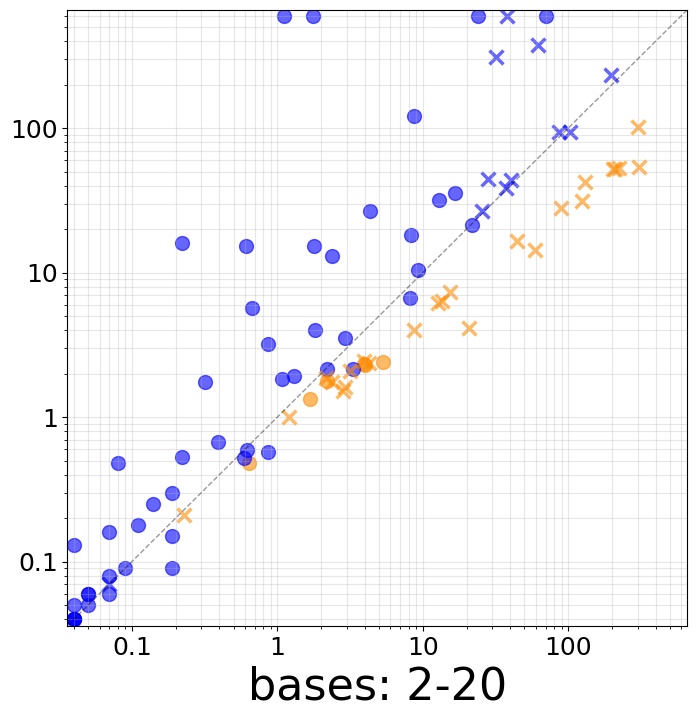

In [11]:
plot_scatter_solvers(
    table =  table_2_20,
    solvers= solvers_2,
    plot_name = 'scatter-2-20-existence.pgf',
    category_col = 'category',                         # column with categories
    category_colors={
        'modular': 'darkorange',
        'random_e': 'blue'
    },
    logscale = True,
    x_label = "bases: 2-20"
)

In [12]:
stats = compute_benchmark_stats(table_2_20, solvers_2)
print_benchmark_stats(stats, solvers_2)

OVERALL PERFORMANCE

sym_2_20:
  Instances:            90
  Solved:               90
  Timeouts:             0
  Total time:           2,666.47 sec
  Geometric mean:       2.5901 sec
  Median time:          2.6100 sec
  Mean time:            29.6274 sec

par_2_20:
  Instances:            90
  Solved:               85
  Timeouts:             5
  Total time:           5,129.53 sec
  Geometric mean:       3.6914 sec
  Median time:          2.8250 sec
  Mean time:            56.9948 sec

RELATIVE PERFORMANCE

Win counts:
  sym_2_20: 42 wins (46.7%)
  par_2_20: 41 wins (45.6%)
  Ties:     7

Speedup statistics:

Speedup of sym_2_20 over par_2_20:
  Median:       1.00x
  Geometric mean: 1.43x
  25th percentile: 0.62x
  75th percentile: 2.18x
  90th percentile: 8.58x

Speedup of par_2_20 over sym_2_20:
  Median:       1.00x
  Geometric mean: 0.70x
  25th percentile: 0.46x
  75th percentile: 1.61x
  90th percentile: 2.99x

Percentage difference (how much slower is par_2_20 vs sym_2_20):
  (Pos

# Benchmark: Split 21-200 - Existence problem

### Instances

In [13]:
solvers_21 = ["sym_21_200","par_21_200"]

# Category: Modular

par_21_200_modular =  pd.read_csv("CSV/modular/21-200/modular-21-par.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_modular =  pd.read_csv("CSV/modular/21-200/modular-21-sym.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

print("Modular tables:", par_21_200_modular.shape[0], sym_21_200_modular.shape[0])

modular_21_200 = pd.merge(par_21_200_modular, sym_21_200_modular, on="instance", how="outer")
clean(modular_21_200, solvers_21)
modular_21_200['category'] = "modular"

# Category: Random (Existence)

par_21_200_random_e =  pd.read_csv("CSV/random/21-200/random-21-par-e.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_random_e =  pd.read_csv("CSV/random/21-200/random-21-sym-e.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

print("Random tables:", par_21_200_random_e.shape[0], sym_21_200_random_e.shape[0])

random_21_200_e = pd.merge(par_21_200_random_e, sym_21_200_random_e, on="instance", how="outer")
clean(random_21_200_e, solvers_21)
random_21_200_e['category'] = "random_e"

# Category: Mixed (Existence)

par_21_200_mixed_e =  pd.read_csv("CSV/mixed/21-200/mixed-21-par-e.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_mixed_e =  pd.read_csv("CSV/mixed/21-200/mixed-21-sym-e.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

print("Mixed tables:", par_21_200_mixed_e.shape[0], sym_21_200_mixed_e.shape[0])

mixed_21_200_e = pd.merge(par_21_200_mixed_e, sym_21_200_mixed_e, on="instance", how="outer")
clean(mixed_21_200_e, solvers_21)
mixed_21_200_e['category'] = "random_e"

# Combine Tables 

table_21_200 = pd.concat([modular_21_200, 
                          random_21_200_e, 
                          # mixed_21_200_e
                         ], ignore_index=True)
table_21_200

Modular tables: 30 30
Random tables: 30 30
Mixed tables: 30 30


,instance,verdict_par_21_200,time_par_21_200,verdict_sym_21_200,time_sym_21_200,category
0,ai-instances/modular/modular_01.smt2,unsat,1.83,unsat,2.14,modular
1,ai-instances/modular/modular_02.smt2,sat,0.39,sat,0.72,modular
2,ai-instances/modular/modular_03.smt2,sat,4.51,sat,8.02,modular
3,ai-instances/modular/modular_04.smt2,sat,0.42,sat,0.53,modular
4,ai-instances/modular/modular_05.smt2,sat,4.45,sat,8.18,modular
5,ai-instances/modular/modular_06.smt2,sat,2.38,sat,5.47,modular
6,ai-instances/modular/modular_07.smt2,sat,0.45,sat,0.79,modular
7,ai-instances/modular/modular_08.smt2,unsat,72.97,unsat,158.56,modular
8,ai-instances/modular/modular_09.smt2,unsat,240.92,unsat,517.90,modular
9,ai-instances/modular/modular_10.smt2,unsat,54.41,unsat,105.28,modular


### Scatter Plot

Unique verdicts for sym_21_200: {'unsat', 'timeout', 'sat'}
Unique verdicts for par_21_200: {'unsat', 'timeout', 'sat'}
Total points to plot: 60
Dots (SAT): 40
Crosses (UNSAT): 14
Squares (TIMEOUT): 6
None/unmatched: 0


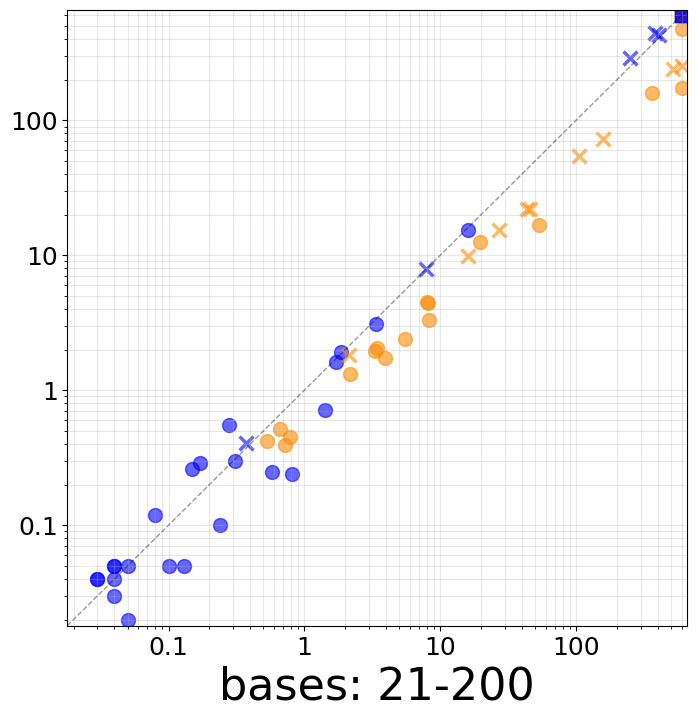

In [14]:
plot_scatter_solvers(
    table = table_21_200,
    solvers= solvers_21,
    plot_name = 'scatter-21-200-existence.pgf',
    category_col = 'category',                         # column with categories
    category_colors = {
        'modular': 'darkorange',
        'random_e': 'blue'
    },
    logscale = True,
    x_label = "bases: 21-200"
)

In [15]:
stats = compute_benchmark_stats(table_21_200, solvers_21)
print_benchmark_stats(stats, solvers_21)

OVERALL PERFORMANCE

sym_21_200:
  Instances:            60
  Solved:               51
  Timeouts:             9
  Total time:           7,873.28 sec
  Geometric mean:       4.8539 sec
  Median time:          3.4000 sec
  Mean time:            131.2213 sec

par_21_200:
  Instances:            60
  Solved:               54
  Timeouts:             6
  Total time:           6,346.43 sec
  Geometric mean:       3.5041 sec
  Median time:          2.0200 sec
  Mean time:            105.7738 sec

RELATIVE PERFORMANCE

Win counts:
  sym_21_200: 13 wins (21.7%)
  par_21_200: 39 wins (65.0%)
  Ties:     8

Speedup statistics:

Speedup of sym_21_200 over par_21_200:
  Median:       0.77x
  Geometric mean: 0.72x
  25th percentile: 0.49x
  75th percentile: 1.00x
  90th percentile: 1.26x

Speedup of par_21_200 over sym_21_200:
  Median:       1.30x
  Geometric mean: 1.39x
  25th percentile: 1.00x
  75th percentile: 2.02x
  90th percentile: 2.41x

Percentage difference (how much slower is par_21_200 

# Benchmark: Split 201-220 - Existence problem

### Instances

In [16]:
solvers_201 = ["sym_201_220","par_201_220"]

# Category: Modular

par_201_220_modular =  pd.read_csv("CSV/modular/201-220/modular-201-par.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_modular =  pd.read_csv("CSV/modular/201-220/modular-201-sym.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

print("Modular tables:", par_201_220_modular.shape[0], sym_201_220_modular.shape[0])

modular_201_220 = pd.merge(par_201_220_modular, sym_201_220_modular, on="instance", how="outer")
clean(modular_201_220, solvers_201)
modular_201_220['category'] = "modular"

# Category: Random (Existence)

par_201_220_random_e =  pd.read_csv("CSV/random/201-220/random-201-par-e.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_random_e =  pd.read_csv("CSV/random/201-220/random-201-sym-e.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

print("Random tables:", par_201_220_random_e.shape[0], sym_201_220_random_e.shape[0])

random_201_220_e = pd.merge(par_201_220_random_e, sym_201_220_random_e, on="instance", how="outer")
clean(random_201_220_e, solvers_201)
random_201_220_e['category'] = "random_e"

# Category: Mixed (Existence)

par_201_220_mixed_e =  pd.read_csv("CSV/mixed/201-220/mixed-201-par-e.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_mixed_e =  pd.read_csv("CSV/mixed/201-220/mixed-201-sym-e.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

print("Mixed tables:", par_201_220_mixed_e.shape[0], sym_201_220_mixed_e.shape[0])

mixed_201_220_e = pd.merge(par_201_220_mixed_e, sym_201_220_mixed_e, on="instance", how="outer")
clean(mixed_201_220_e, solvers_201)
mixed_201_220_e['category'] = "random_e"

# Combine Tables 

table_201_220 = pd.concat([modular_201_220, random_201_220_e, mixed_201_220_e], ignore_index=True)
table_201_220

Modular tables: 30 30
Random tables: 30 30
Mixed tables: 30 30


,instance,verdict_par_201_220,time_par_201_220,verdict_sym_201_220,time_sym_201_220,category
0,ai-instances/modular/modular_01.smt2,unsat,0.25,unsat,0.25,modular
1,ai-instances/modular/modular_02.smt2,sat,0.38,sat,0.77,modular
2,ai-instances/modular/modular_03.smt2,sat,4.02,sat,6.47,modular
3,ai-instances/modular/modular_04.smt2,sat,0.29,sat,0.54,modular
4,ai-instances/modular/modular_05.smt2,sat,4.80,sat,6.63,modular
...,...,...,...,...,...,...
85,ai-instances/random-mixed/mixed_26.smt2,unsat,32.74,unsat,55.96,random_e
86,ai-instances/random-mixed/mixed_27.smt2,sat,3.51,sat,0.61,random_e
87,ai-instances/random-mixed/mixed_28.smt2,sat,0.04,sat,0.03,random_e
88,ai-instances/random-mixed/mixed_29.smt2,sat,2.46,sat,2.51,random_e


### Scatter Plot

Unique verdicts for sym_201_220: {'unsat', 'sat'}
Unique verdicts for par_201_220: {'unsat', 'sat'}
Total points to plot: 90
Dots (SAT): 55
Crosses (UNSAT): 35
Squares (TIMEOUT): 0
None/unmatched: 0


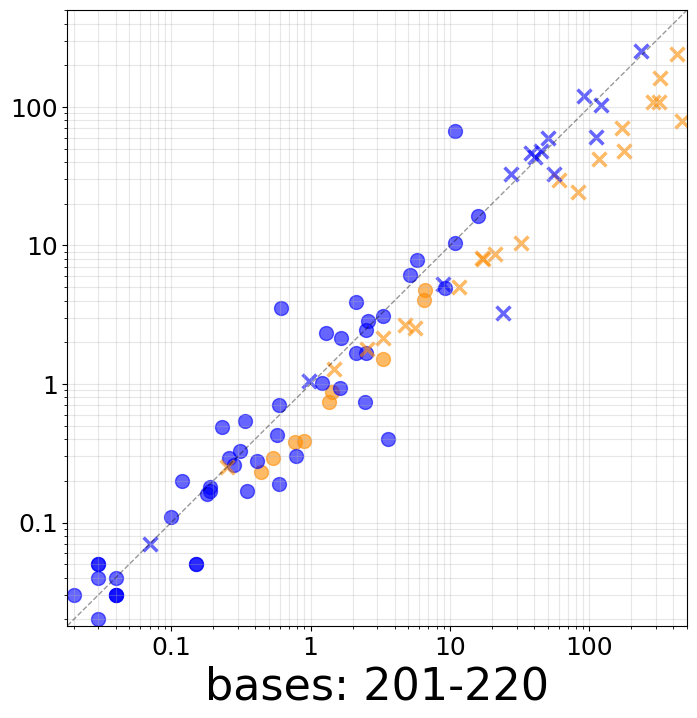

In [17]:
plot_scatter_solvers(
    table = table_201_220,
    solvers= solvers_201,
    plot_name='scatter-201-220-existence.pgf',
    category_col='category',                         # column with categories
    category_colors={
        'modular': 'darkorange',
        'random_e': 'blue'
    },
    logscale = True,
    x_label = "bases: 201-220"
)

In [18]:
stats = compute_benchmark_stats(table_201_220, solvers_201)
print_benchmark_stats(stats, solvers_201)

OVERALL PERFORMANCE

sym_201_220:
  Instances:            90
  Solved:               90
  Timeouts:             0
  Total time:           3,488.48 sec
  Geometric mean:       2.6539 sec
  Median time:          2.4800 sec
  Mean time:            38.7609 sec

par_201_220:
  Instances:            90
  Solved:               90
  Timeouts:             0
  Total time:           1,931.19 sec
  Geometric mean:       1.9389 sec
  Median time:          1.9750 sec
  Mean time:            21.4577 sec

RELATIVE PERFORMANCE

Win counts:
  sym_201_220: 28 wins (31.1%)
  par_201_220: 59 wins (65.6%)
  Ties:     3

Speedup statistics:

Speedup of sym_201_220 over par_201_220:
  Median:       0.75x
  Geometric mean: 0.73x
  25th percentile: 0.49x
  75th percentile: 1.08x
  90th percentile: 1.51x

Speedup of par_201_220 over sym_201_220:
  Median:       1.33x
  Geometric mean: 1.37x
  25th percentile: 0.92x
  75th percentile: 2.05x
  90th percentile: 3.00x

Percentage difference (how much slower is par_2

# Benchmark: Split 2-21 - Universality problem 

### Instances

In [19]:
solvers_2 = ["sym_2_20","par_2_20"]

# Category: Modular

par_2_20_divisibility =  pd.read_csv("CSV/divisibility/2-20/divisibility-2-par-u.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_divisibility =  pd.read_csv("CSV/divisibility/2-20/divisibility-2-sym-u.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

print("Divisibility tables:", par_2_20_divisibility.shape[0], sym_2_20_divisibility.shape[0])

divisibility_2_20 = pd.merge(par_2_20_divisibility, sym_2_20_divisibility, on="instance", how="outer")
clean(divisibility_2_20, solvers_2)
divisibility_2_20['category'] = "divisibility"

# Category: Random (Universality)

par_2_20_random_u =  pd.read_csv("CSV/random/2-20/random-2-par-u.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_random_u =  pd.read_csv("CSV/random/2-20/random-2-sym-u.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

print("Random tables:", par_2_20_random_u.shape[0], sym_2_20_random_u.shape[0])

random_2_20_u = pd.merge(par_2_20_random_u, sym_2_20_random_u, on="instance", how="outer")
clean(random_2_20_u, solvers_2)
random_2_20_u['category'] = "random_u"

# Category: Mixed (Universality)

par_2_20_mixed_u =  pd.read_csv("CSV/mixed/2-20/mixed-2-par-u.csv").rename(columns={'output': 'verdict_par_2_20', 'time': 'time_par_2_20'})
sym_2_20_mixed_u =  pd.read_csv("CSV/mixed/2-20/mixed-2-sym-u.csv").rename(columns={'output': 'verdict_sym_2_20', 'time': 'time_sym_2_20'})

print("Mixed tables:", par_2_20_mixed_u.shape[0], sym_2_20_mixed_u.shape[0])

mixed_2_20_u = pd.merge(par_2_20_mixed_u, sym_2_20_mixed_u, on="instance", how="outer")
clean(mixed_2_20_u, solvers_2)
mixed_2_20_u['category'] = "random_u"

# Combine Tables 

table_2_20 = pd.concat([divisibility_2_20, 
                        random_2_20_u, 
                        mixed_2_20_u
                        ], ignore_index=True)
table_2_20

Divisibility tables: 30 30
Random tables: 30 30
Mixed tables: 30 30


,instance,verdict_par_2_20,time_par_2_20,verdict_sym_2_20,time_sym_2_20,category
0,ai-instances/divisibility/divisibility_01.smt2,sat,0.12,sat,0.30,divisibility
1,ai-instances/divisibility/divisibility_02.smt2,sat,2.27,sat,4.58,divisibility
2,ai-instances/divisibility/divisibility_03.smt2,sat,0.12,sat,0.47,divisibility
3,ai-instances/divisibility/divisibility_04.smt2,sat,41.03,sat,40.44,divisibility
4,ai-instances/divisibility/divisibility_05.smt2,sat,0.09,sat,0.10,divisibility
...,...,...,...,...,...,...
85,ai-instances/random-mixed/mixed_26.smt2,unsat,92.83,unsat,2.30,random_u
86,ai-instances/random-mixed/mixed_27.smt2,sat,53.78,sat,44.95,random_u
87,ai-instances/random-mixed/mixed_28.smt2,sat,0.22,sat,0.27,random_u
88,ai-instances/random-mixed/mixed_29.smt2,unsat,0.52,unsat,0.41,random_u


### Scatter plot

Unique verdicts for sym_2_20: {'unsat', 'timeout', 'sat'}
Unique verdicts for par_2_20: {'unsat', 'timeout', 'sat'}
Total points to plot: 90
Dots (SAT): 47
Crosses (UNSAT): 25
Squares (TIMEOUT): 18
None/unmatched: 0


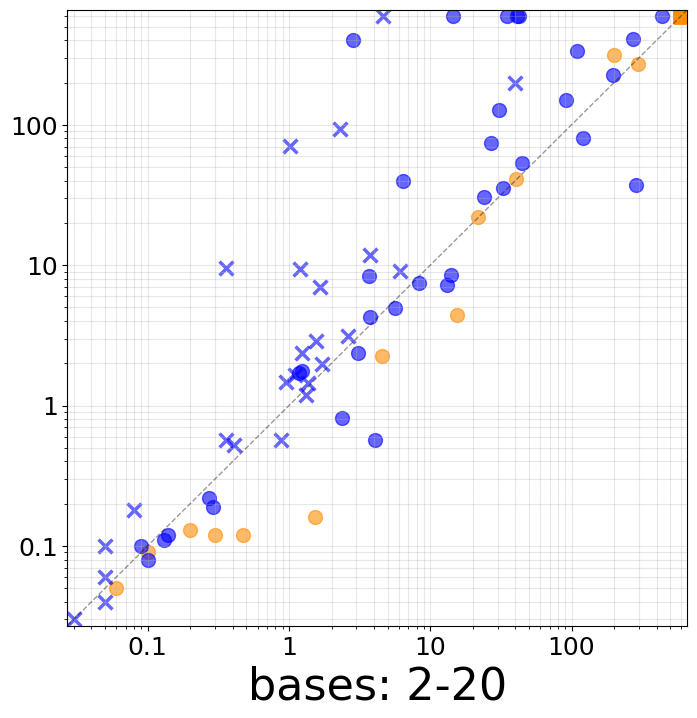

In [20]:
plot_scatter_solvers(
    table =  table_2_20,
    solvers= solvers_2,
    plot_name = 'scatter-2-20-universality.pgf',
    category_col = 'category',                         # column with categories
    category_colors={
        'divisibility': 'darkorange',
        'random_u': 'blue'
    },
    logscale = True,
    x_label = "bases: 2-20"
)

In [21]:
stats = compute_benchmark_stats(table_2_20, solvers_2)
print_benchmark_stats(stats, solvers_2)

OVERALL PERFORMANCE

sym_2_20:
  Instances:            90
  Solved:               72
  Timeouts:             18
  Total time:           13,333.66 sec
  Geometric mean:       9.0354 sec
  Median time:          5.8800 sec
  Mean time:            148.1518 sec

par_2_20:
  Instances:            90
  Solved:               66
  Timeouts:             24
  Total time:           17,527.11 sec
  Geometric mean:       13.7276 sec
  Median time:          10.7300 sec
  Mean time:            194.7457 sec

RELATIVE PERFORMANCE

Win counts:
  sym_2_20: 45 wins (50.0%)
  par_2_20: 26 wins (28.9%)
  Ties:     19

Speedup statistics:

Speedup of sym_2_20 over par_2_20:
  Median:       1.01x
  Geometric mean: 1.52x
  25th percentile: 0.89x
  75th percentile: 1.62x
  90th percentile: 8.51x

Speedup of par_2_20 over sym_2_20:
  Median:       0.99x
  Geometric mean: 0.66x
  25th percentile: 0.62x
  75th percentile: 1.13x
  90th percentile: 1.65x

Percentage difference (how much slower is par_2_20 vs sym_2_20

# Benchmark: Split 21-200 - Universality problem 

### Instances

In [22]:
solvers_21 = ["sym_21_200","par_21_200"]

# Category: Divisibility

par_21_200_divisibility =  pd.read_csv("CSV/divisibility/21-200/divisibility-21-par-u.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_divisibility =  pd.read_csv("CSV/divisibility/21-200/divisibility-21-sym-u.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

print("Divisibility tables:", par_21_200_divisibility.shape[0], sym_21_200_divisibility.shape[0])

divisibility_21_200 = pd.merge(par_21_200_divisibility, sym_21_200_divisibility, on="instance", how="outer")
clean(divisibility_21_200, solvers_21)
divisibility_21_200['category'] = "divisibility"

# Category: Random (Universality)

par_21_200_random_u =  pd.read_csv("CSV/random/21-200/random-21-par-u.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_random_u =  pd.read_csv("CSV/random/21-200/random-21-sym-u.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

print("Random tables:", par_21_200_random_u.shape[0], sym_21_200_random_u.shape[0])

random_21_200_u = pd.merge(par_21_200_random_u, sym_21_200_random_u, on="instance", how="outer")
clean(random_21_200_u, solvers_21)
random_21_200_u['category'] = "random_u"

# Category: Mixed (Universality)

par_21_200_mixed_u =  pd.read_csv("CSV/mixed/21-200/mixed-21-par-u.csv").rename(columns={'output': 'verdict_par_21_200', 'time': 'time_par_21_200'})
sym_21_200_mixed_u =  pd.read_csv("CSV/mixed/21-200/mixed-21-sym-u.csv").rename(columns={'output': 'verdict_sym_21_200', 'time': 'time_sym_21_200'})

print("Mixed tables:", par_21_200_mixed_u.shape[0], sym_21_200_mixed_u.shape[0])

mixed_21_200_u = pd.merge(par_21_200_mixed_u, sym_21_200_mixed_u, on="instance", how="outer")
clean(mixed_21_200_u, solvers_21)
mixed_21_200_u['category'] = "random_u"

# Combine Tables 

table_21_200 = pd.concat([divisibility_21_200, 
                          random_21_200_u, 
                          mixed_21_200_u
                         ], ignore_index=True)
table_21_200

Divisibility tables: 30 32
Random tables: 30 30
Mixed tables: 30 30


,instance,verdict_par_21_200,time_par_21_200,verdict_sym_21_200,time_sym_21_200,category
0,ai-instances/divisibility/divisibility_01.smt2,sat,0.41,sat,2.41,divisibility
1,ai-instances/divisibility/divisibility_02.smt2,sat,1.00,sat,30.84,divisibility
2,ai-instances/divisibility/divisibility_03.smt2,sat,0.44,sat,2.40,divisibility
3,ai-instances/divisibility/divisibility_04.smt2,sat,1.81,sat,99.56,divisibility
4,ai-instances/divisibility/divisibility_05.smt2,sat,0.31,sat,0.66,divisibility
...,...,...,...,...,...,...
87,ai-instances/random-mixed/mixed_26.smt2,unsat,2.01,unsat,5.40,random_u
88,ai-instances/random-mixed/mixed_27.smt2,sat,243.20,sat,353.22,random_u
89,ai-instances/random-mixed/mixed_28.smt2,sat,1.97,sat,2.61,random_u
90,ai-instances/random-mixed/mixed_29.smt2,sat,341.52,sat,337.44,random_u


### Scatter plot

Unique verdicts for sym_21_200: {'unsat', 'timeout', 'sat'}
Unique verdicts for par_21_200: {'unsat', 'timeout', 'sat'}
Total points to plot: 92
Dots (SAT): 61
Crosses (UNSAT): 15
Squares (TIMEOUT): 16
None/unmatched: 0


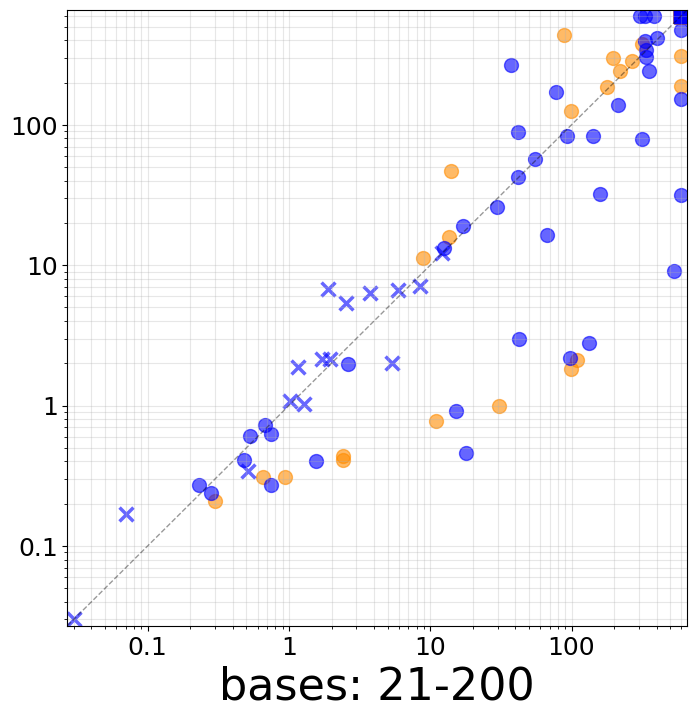

In [23]:
plot_scatter_solvers(
    table =  table_21_200,
    solvers= solvers_21,
    plot_name = 'scatter-21-200-universality.pgf',
    category_col = 'category',                         # column with categories
    category_colors={
        'divisibility': 'darkorange',
        'random_u': 'blue'
    },
    logscale = True,
    x_label = "bases: 21-200"
)

In [24]:
stats = compute_benchmark_stats(table_21_200, solvers_21)
print_benchmark_stats(stats, solvers_21)

OVERALL PERFORMANCE

sym_21_200:
  Instances:            92
  Solved:               71
  Timeouts:             21
  Total time:           19,222.43 sec
  Geometric mean:       34.2979 sec
  Median time:          82.4450 sec
  Mean time:            208.9395 sec

par_21_200:
  Instances:            92
  Solved:               73
  Timeouts:             19
  Total time:           17,485.30 sec
  Geometric mean:       21.4391 sec
  Median time:          31.9300 sec
  Mean time:            190.0576 sec

RELATIVE PERFORMANCE

Win counts:
  sym_21_200: 36 wins (39.1%)
  par_21_200: 39 wins (42.4%)
  Ties:     17

Speedup statistics:

Speedup of sym_21_200 over par_21_200:
  Median:       1.00x
  Geometric mean: 0.63x
  25th percentile: 0.51x
  75th percentile: 1.12x
  90th percentile: 1.80x

Speedup of par_21_200 over sym_21_200:
  Median:       1.00x
  Geometric mean: 1.60x
  25th percentile: 0.89x
  75th percentile: 1.98x
  90th percentile: 14.33x

Percentage difference (how much slower is p

# Benchmark: Split 201-220 - Universality problem 

### Instances

In [25]:
solvers_201 = ["sym_201_220","par_201_220"]

# Category: Divisibility

par_201_220_divisibility =  pd.read_csv("CSV/divisibility/201-220/divisibility-201-par-u.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_divisibility =  pd.read_csv("CSV/divisibility/201-220/divisibility-201-sym-u.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

print("Divisibility tables:", par_201_220_divisibility.shape[0], sym_201_220_divisibility.shape[0])

divisibility_201_220 = pd.merge(par_201_220_divisibility, sym_201_220_divisibility, on="instance", how="outer")
clean(divisibility_201_220, solvers_201)
divisibility_201_220['category'] = "divisibility"

# Category: Random (Universality)

par_201_220_random_u =  pd.read_csv("CSV/random/201-220/random-201-par-u.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_random_u =  pd.read_csv("CSV/random/201-220/random-201-sym-u.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

print("Random tables:", par_201_220_random_u.shape[0], sym_201_220_random_u.shape[0])

random_201_220_u = pd.merge(par_201_220_random_u, sym_201_220_random_u, on="instance", how="outer")
clean(random_201_220_u, solvers_201)
random_201_220_u['category'] = "random_u"

# Category: Mixed (Universality)

par_201_220_mixed_u =  pd.read_csv("CSV/mixed/201-220/mixed-201-par-u.csv").rename(columns={'output': 'verdict_par_201_220', 'time': 'time_par_201_220'})
sym_201_220_mixed_u =  pd.read_csv("CSV/mixed/201-220/mixed-201-sym-u.csv").rename(columns={'output': 'verdict_sym_201_220', 'time': 'time_sym_201_220'})

print("Mixed tables:", par_201_220_mixed_u.shape[0], sym_201_220_mixed_u.shape[0])

mixed_201_220_u = pd.merge(par_201_220_mixed_u, sym_201_220_mixed_u, on="instance", how="outer")
clean(mixed_201_220_u, solvers_201)
mixed_201_220_u['category'] = "random_u"

# Combine Tables 

table_201_220 = pd.concat([divisibility_201_220, 
                            random_201_220_u, 
                            mixed_201_220_u
                            ], ignore_index=True)
table_201_220

Divisibility tables: 30 30
Random tables: 30 30
Mixed tables: 30 30


,instance,verdict_par_201_220,time_par_201_220,verdict_sym_201_220,time_sym_201_220,category
0,ai-instances/divisibility/divisibility_01.smt2,sat,0.07,sat,0.30,divisibility
1,ai-instances/divisibility/divisibility_02.smt2,sat,0.17,sat,3.49,divisibility
2,ai-instances/divisibility/divisibility_03.smt2,sat,0.08,sat,0.28,divisibility
3,ai-instances/divisibility/divisibility_04.smt2,sat,0.37,sat,9.84,divisibility
4,ai-instances/divisibility/divisibility_05.smt2,sat,0.07,sat,0.10,divisibility
...,...,...,...,...,...,...
85,ai-instances/random-mixed/mixed_26.smt2,unsat,1.89,unsat,3.07,random_u
86,ai-instances/random-mixed/mixed_27.smt2,sat,22.52,sat,34.70,random_u
87,ai-instances/random-mixed/mixed_28.smt2,sat,0.20,sat,0.29,random_u
88,ai-instances/random-mixed/mixed_29.smt2,sat,27.30,sat,36.55,random_u


Unique verdicts for sym_201_220: {'unsat', 'sat'}
Unique verdicts for par_201_220: {'unsat', 'timeout', 'sat'}
Total points to plot: 90
Dots (SAT): 75
Crosses (UNSAT): 15
Squares (TIMEOUT): 0
None/unmatched: 0


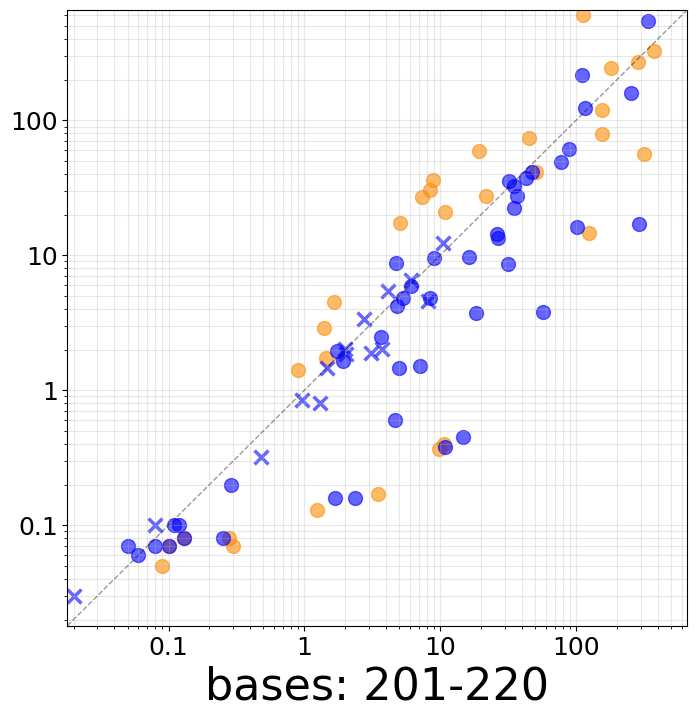

In [26]:
plot_scatter_solvers(
    table =  table_201_220,
    solvers= solvers_201,
    plot_name = 'scatter-201-220-universality.pgf',
    category_col = 'category',                         # column with categories
    category_colors={
        'divisibility': 'darkorange',
        'random_u': 'blue'
    },
    logscale = True,
    x_label = "bases: 201-220"
)

In [27]:
stats = compute_benchmark_stats(table_201_220, solvers_201)
print_benchmark_stats(stats, solvers_201)

OVERALL PERFORMANCE

sym_201_220:
  Instances:            90
  Solved:               90
  Timeouts:             0
  Total time:           3,835.23 sec
  Geometric mean:       5.7258 sec
  Median time:          6.5950 sec
  Mean time:            42.6137 sec

par_201_220:
  Instances:            90
  Solved:               89
  Timeouts:             1
  Total time:           3,585.52 sec
  Geometric mean:       3.5369 sec
  Median time:          4.3600 sec
  Mean time:            39.8391 sec

RELATIVE PERFORMANCE

Win counts:
  sym_201_220: 29 wins (32.2%)
  par_201_220: 60 wins (66.7%)
  Ties:     1

Speedup statistics:

Speedup of sym_201_220 over par_201_220:
  Median:       0.83x
  Geometric mean: 0.62x
  25th percentile: 0.52x
  75th percentile: 1.17x
  90th percentile: 1.91x

Speedup of par_201_220 over sym_201_220:
  Median:       1.21x
  Geometric mean: 1.62x
  25th percentile: 0.86x
  75th percentile: 1.93x
  90th percentile: 9.64x

Percentage difference (how much slower is par_2